Importing libraries

In [6]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

importing csv file

In [11]:

df = pd.read_csv('student_feedback.csv', index_col = 0)
df.head()

,Student ID,Well versed with the subject,Explains concepts in an understandable way,Use of presentations,Degree of difficulty of assignments,Solves doubts willingly,Structuring of the course,Provides support for students going above and beyond,Course recommendation based on relevance
0,340,5,2,7,6,9,2,1,8
1,253,6,5,8,6,2,1,2,9
2,680,7,7,6,5,4,2,3,1
3,806,9,6,7,1,5,9,4,6
4,632,8,10,8,4,6,6,9,9


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1001 entries, 0 to 1000
Data columns (total 9 columns):
 #   Column                                                Non-Null Count  Dtype
---  ------                                                --------------  -----
 0   Student ID                                            1001 non-null   int64
 1   Well versed with the subject                          1001 non-null   int64
 2   Explains concepts in an understandable way            1001 non-null   int64
 3   Use of presentations                                  1001 non-null   int64
 4   Degree of difficulty of assignments                   1001 non-null   int64
 5   Solves doubts willingly                               1001 non-null   int64
 6   Structuring of the course                             1001 non-null   int64
 7   Provides support for students going above and beyond  1001 non-null   int64
 8   Course recommendation based on relevance              1001 non-null   int64
dtypes: 

In [13]:
df.shape

(1001, 9)

Statistical summary

In [14]:
df.describe().round(2)

,Student ID,Well versed with the subject,Explains concepts in an understandable way,Use of presentations,Degree of difficulty of assignments,Solves doubts willingly,Structuring of the course,Provides support for students going above and beyond,Course recommendation based on relevance
count,1001.00,1001.00,1001.00,1001.00,1001.00,1001.00,1001.00,1001.00,1001.00
mean,500.00,7.50,6.08,5.94,5.43,5.47,5.64,5.66,5.60
std,289.11,1.69,2.60,1.42,2.87,2.87,2.92,2.89,2.89
min,0.00,5.00,2.00,4.00,1.00,1.00,1.00,1.00,1.00
25%,250.00,6.00,4.00,5.00,3.00,3.00,3.00,3.00,3.00
50%,500.00,8.00,6.00,6.00,5.00,6.00,6.00,6.00,6.00
75%,750.00,9.00,8.00,7.00,8.00,8.00,8.00,8.00,8.00
max,1000.00,10.00,10.00,8.00,10.00,10.00,10.00,10.00,10.00


Checking null values


In [15]:
display(df.isna().sum())

Student ID                                              0
Well versed with the subject                            0
Explains concepts in an understandable way              0
Use of presentations                                    0
Degree of difficulty of assignments                     0
Solves doubts willingly                                 0
Structuring of the course                               0
Provides support for students going above and beyond    0
Course recommendation based on relevance                0
dtype: int64

Average Feedback Ratings

C:\Users\HP PC\AppData\Local\Temp\ipykernel_25316\4018985078.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


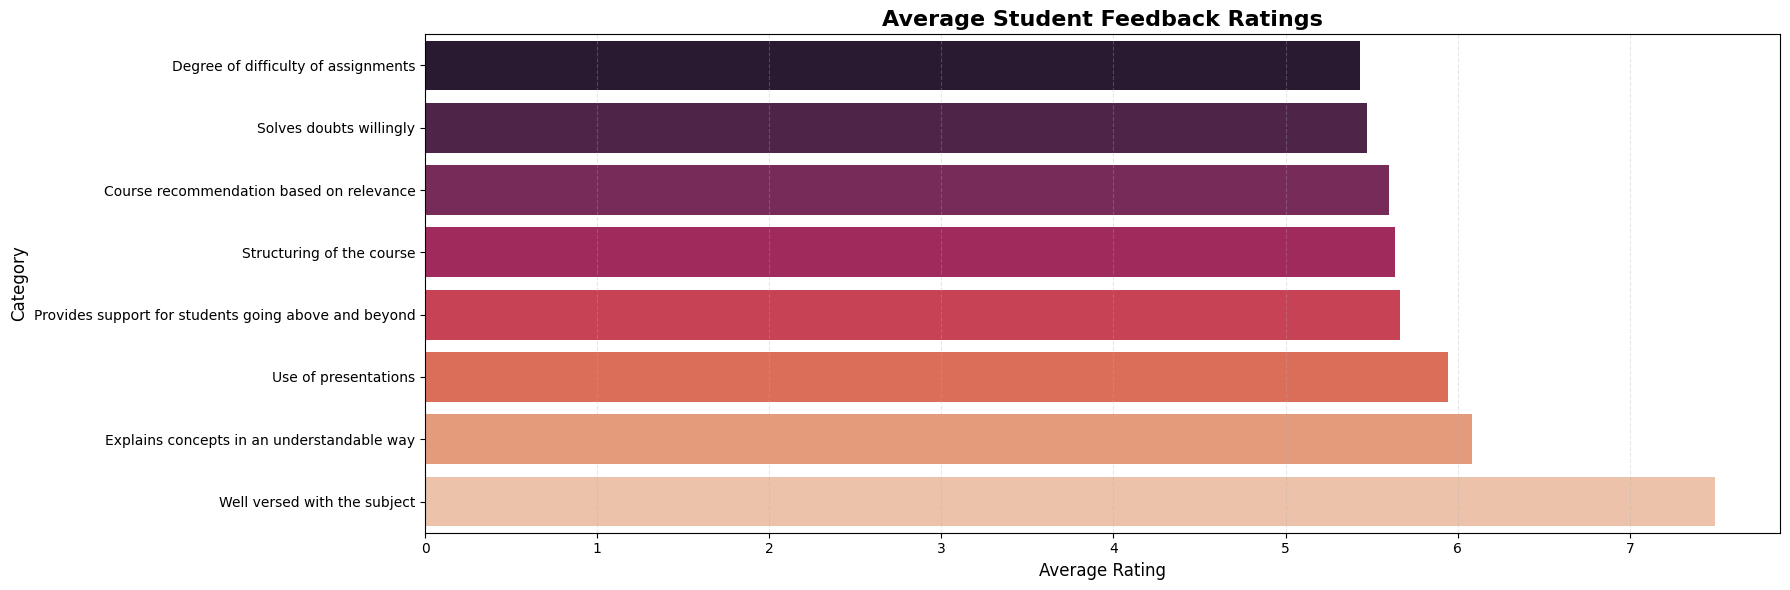

In [34]:

# Drop non-rating column
df = data.drop(columns=['Student ID'])

# Calculate average ratings
average_ratings = df.mean().sort_values(ascending=True)

# Plot
plt.figure(figsize=(18, 6))
sns.barplot(
    x=average_ratings.values,
    y=average_ratings.index,
    palette="rocket"
)

plt.xlabel("Average Rating", fontsize=12)
plt.ylabel("Category", fontsize=12)
plt.title("Average Student Feedback Ratings", fontsize=16, weight="bold")
plt.grid(axis="x", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()


Correlation Heatmap of Feedback Ratings

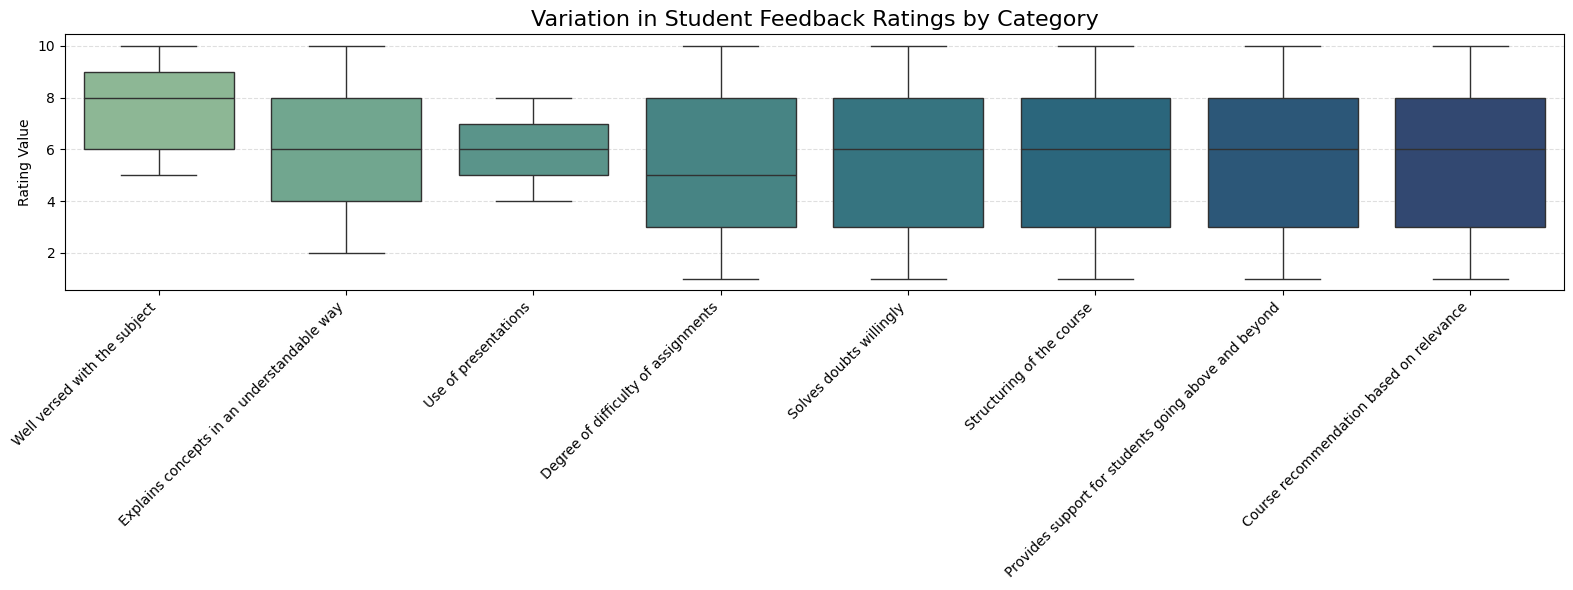

In [35]:
plt.figure(figsize=(16, 6))

sns.boxplot(
    data=df,
    palette="crest"
)

plt.title("Variation in Student Feedback Ratings by Category", fontsize=16)
plt.ylabel("Rating Value")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

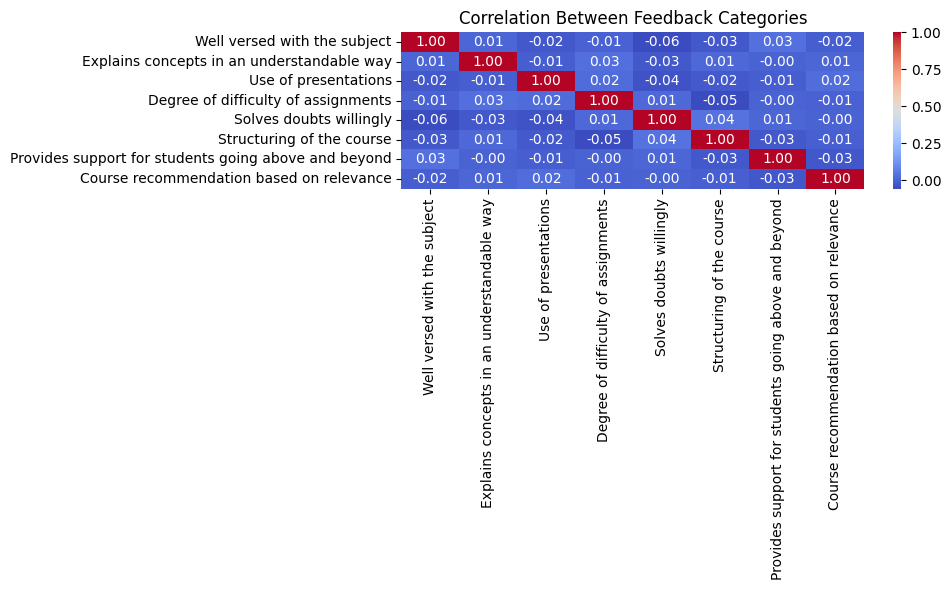

In [22]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Between Feedback Categories")
plt.tight_layout()
plt.show()


Sentiment

In [25]:
print(df.columns)


Index(['Well versed with the subject',
       'Explains concepts in an understandable way', 'Use of presentations',
       'Degree of difficulty of assignments', 'Solves doubts willingly',
       'Structuring of the course',
       'Provides support for students going above and beyond',
       'Course recommendation based on relevance'],
      dtype='object')


In [36]:
sentiment_df = df.copy()
# rating per column 
max_ratings = sentiment_df[average_ratings.index].max()
#percentage of the maximum possible rating
percent_scores = sentiment_df[average_ratings.index].apply(lambda col: col / max_ratings[col.name] * 100)
# overall satisfaction as the mean of all percentage scores per student
sentiment_df["overall_satisfaction_percent"] = percent_scores.mean(axis=1)
# Preview
sentiment_df.head()


,Well versed with the subject,Explains concepts in an understandable way,Use of presentations,Degree of difficulty of assignments,Solves doubts willingly,Structuring of the course,Provides support for students going above and beyond,Course recommendation based on relevance,overall_satisfaction_percent
0,5,2,7,6,9,2,1,8,52.1875
1,6,5,8,6,2,1,2,9,51.2500
2,7,7,6,5,4,2,3,1,45.6250
3,9,6,7,1,5,9,4,6,60.9375
4,8,10,8,4,6,6,9,9,77.5000


In [ ]:
#sentiment based on overall satisfaction percentage
def classify_sentiment(percent):
    if percent >= 70:       # 70% and above → Positive
        return "Positive"
    elif percent >= 40:     # 40%–69% → Neutral
        return "Neutral"
    else:                   # below 40% → Negative
        return "Negative"

# classification
sentiment_df["sentiment"] = sentiment_df["overall_satisfaction_percent"].apply(classify_sentiment)

# Preview
sentiment_df[["overall_satisfaction_percent", "sentiment"]].head()


,overall_satisfaction_percent,sentiment
0,52.1875,Neutral
1,51.2500,Neutral
2,45.6250,Neutral
3,60.9375,Neutral
4,77.5000,Positive


Count sentiment

In [29]:
sentiment_counts = sentiment_df["sentiment"].value_counts()
print(sentiment_counts)

sentiment
Neutral     819
Positive    174
Negative      8
Name: count, dtype: int64


 Sentiment Counts Plot-Bar chart

C:\Users\HP PC\AppData\Local\Temp\ipykernel_25316\3049944874.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


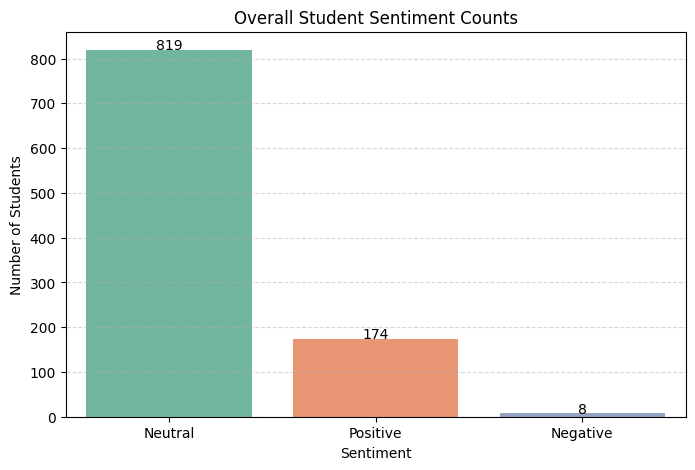

In [32]:
plt.figure(figsize=(8,5))
sns.barplot(
    x=sentiment_counts.index,
    y=sentiment_counts.values,
    palette="Set2"
)

plt.xlabel("Sentiment")
plt.ylabel("Number of Students")
plt.title("Overall Student Sentiment Counts")
plt.grid(axis="y", linestyle="--", alpha=0.5)

# Add value labels
for i, v in enumerate(sentiment_counts.values):
    plt.text(i, v + 0.5, str(v), ha="center", fontsize=10)

plt.show()


Sentiment plot -Pie Chart

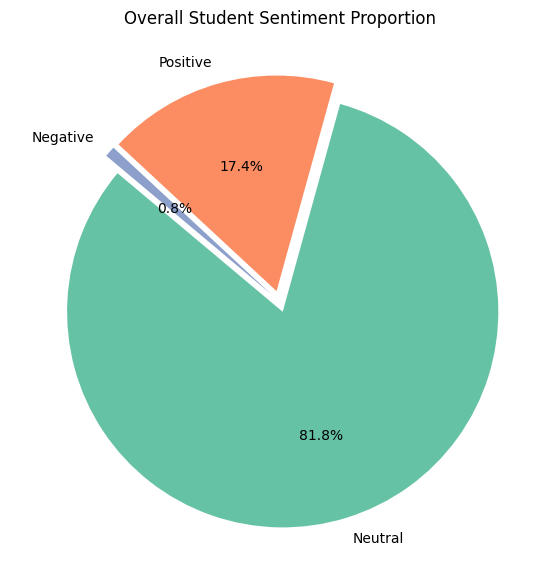

In [31]:
plt.figure(figsize=(7,7))
colors = sns.color_palette("Set2")[0:3]

plt.pie(
    sentiment_counts.values,
    labels=sentiment_counts.index,
    autopct="%1.1f%%",
    startangle=140,
    colors=colors,
    explode=[0.05, 0.05, 0.05]
)

plt.title("Overall Student Sentiment Proportion")
plt.show()
